In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import json
import shutil

print("All imports successful!")

All imports successful!


In [2]:
# Paths
BASE_DIR      = Path("D:/MaternaVision")
RAW_DIR       = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
TRAIN_DIR     = RAW_DIR  / "training_set"
TEST_DIR      = RAW_DIR  / "test_set"
TRAIN_CSV     = RAW_DIR  / "training_set_pixel_size_and_HC.csv"
TEST_CSV      = RAW_DIR  / "test_set_pixel_size.csv"

# Target image size
IMAGE_SIZE = 256

# Create processed folders
(PROCESSED_DIR / "images" / "train").mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "images" / "val").mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "images" / "test").mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "masks"  / "train").mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "masks"  / "val").mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "landmarks").mkdir(parents=True, exist_ok=True)

print("All folders created!")
print(f"Processing images to size: {IMAGE_SIZE}x{IMAGE_SIZE}")

All folders created!
Processing images to size: 256x256


In [3]:
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print("Training CSV columns:", list(df_train.columns))
print("Training samples    :", len(df_train))
print()
print(df_train.head())

Training CSV columns: ['filename', 'pixel size(mm)', 'head circumference (mm)']
Training samples    : 999

     filename  pixel size(mm)  head circumference (mm)
0  000_HC.png        0.069136                    44.30
1  001_HC.png        0.089659                    56.81
2  002_HC.png        0.062033                    68.75
3  003_HC.png        0.091291                    69.00
4  004_HC.png        0.061240                    59.81


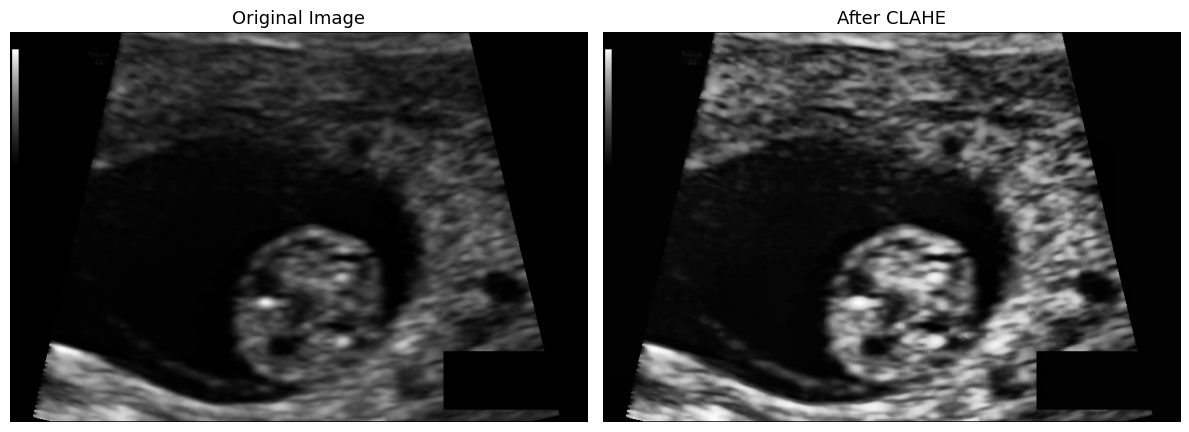

CLAHE working correctly!


In [4]:
def apply_clahe(image):
    """
    Apply CLAHE to enhance local contrast
    in ultrasound images.
    """
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    return clahe.apply(image)


# Test CLAHE on one image
sample_path = list(TRAIN_DIR.glob("*_HC.png"))[0]
sample_img  = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
clahe_img   = apply_clahe(sample_img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(sample_img,  cmap='gray')
axes[0].set_title('Original Image', fontsize=13)
axes[0].axis('off')
axes[1].imshow(clahe_img, cmap='gray')
axes[1].set_title('After CLAHE', fontsize=13)
axes[1].axis('off')
plt.tight_layout()
plt.savefig('clahe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("CLAHE working correctly!")